# Medical Sound Classification

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchaudio
import timm
import librosa
import librosa.display
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

c:\Users\briek\.virtualenvs\Deep_learning_project-8qJO88P_\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Exploratory Analysis

## 1.1 Laad dataset

In [3]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

## 1.2 Bekijk class balance

In [52]:
df_train.head()

,candidateID,age,gender,tbContactHistory,wheezingHistory,phlegmCough,familyAsthmaHistory,feverHistory,coldPresent,packYears,disease
0,b87ea0dd760fa,43,1,0.0,1.0,0.0,0.0,0,NaN,0,1
1,b734834dec6d1,24,0,0.0,1.0,0.0,0.0,0,NaN,0,1
2,e000a41725f53,52,1,0.0,1.0,0.0,0.0,0,NaN,0,2
3,253ba780a0398,28,0,0.0,0.0,0.0,0.0,0,NaN,0,0
4,6663cd023ff3d,27,1,0.0,1.0,0.0,1.0,0,NaN,0,1


In [53]:
print(df_train['disease'].value_counts())


disease
1    238
2    168
0    140
Name: count, dtype: int64


Redelijk wat imbalance.

* 0 : 140
* 1 : 238
* 2 : 168

### 1.2.1 We plotten

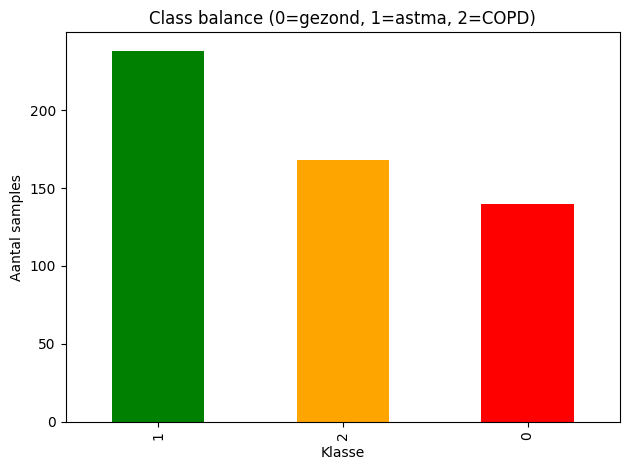

In [54]:
import matplotlib.pyplot as plt
df_train['disease'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Class balance (0=gezond, 1=astma, 2=COPD)')
plt.xlabel('Klasse')
plt.ylabel('Aantal samples')
plt.tight_layout()
plt.show()

## 1.3 Bekijk audio bestanden

In [55]:
import librosa
import os

sample_id = df_train['candidateID'].iloc[0]

wav_path = f'data/sounds/sounds/{sample_id}/cough.wav'

y, sr = librosa.load(wav_path, sr=None)
print(f"Sample rate: {sr} Hz")
print(f"Duur: {len(y)/sr:.2f} seconden")
print(f"Aantal samples: {len(y)}")

print("\n=== DUUR VAN EERSTE 5 BESTANDEN ===")
for cid in df_train['candidateID'].head(5):
    path = f'data/sounds/sounds/{cid}/cough.wav'
    y, sr = librosa.load(path, sr=None)
    print(f"{cid}: {len(y)/sr:.2f}s  (sr={sr})")

Sample rate: 48000 Hz
Duur: 10.07 seconden
Aantal samples: 483328

=== DUUR VAN EERSTE 5 BESTANDEN ===
b87ea0dd760fa: 10.07s  (sr=48000)
b734834dec6d1: 18.43s  (sr=48000)
e000a41725f53: 12.63s  (sr=48000)
253ba780a0398: 9.13s  (sr=48000)
6663cd023ff3d: 9.98s  (sr=48000)


Sample rate : 48.000 Hz (gaan we veranderen naar 16.000 hz)
Duur: varieert sterk. (gaan we truncaten/padden naar een vaste lengte)

## 1.4 Feature check (check voor NaN's, strings etc)

In [56]:
df_train.isnull().sum()

candidateID              0
age                      0
gender                   0
tbContactHistory         0
wheezingHistory          0
phlegmCough              0
familyAsthmaHistory      0
feverHistory             0
coldPresent            148
packYears                0
disease                  0
dtype: int64

coldPresent (of dat ze verkouden waren of niet tijdens checkup) : 148 NaN's

In [57]:
df_train.dtypes

candidateID                str
age                      int64
gender                   int64
tbContactHistory       float64
wheezingHistory        float64
phlegmCough            float64
familyAsthmaHistory    float64
feverHistory             int64
coldPresent            float64
packYears                int64
disease                  int64
dtype: object

Perfect, alles staat in numerieke waarde. candidateID laten we als string, dit wordt gewoon gebruikt om de .wav te linken.

# 2 Audio preprocessing

Eerst zullen we eens kijken naar de code die aan ons is gegeven op kaggle.

In [58]:
def pad_audio(y, target_length):
    """Pads the audio with zeros to match the target length."""
    if len(y) < target_length:
        padding = target_length - len(y)
        y = np.pad(y, (0, padding), 'constant')
    return y

def truncate_audio(y, target_length):
    """Truncates the audio to match the target length."""
    if len(y) > target_length:
        y = y[:target_length]
    return y

def adjust_audio(y, target_length=32000):
    """Adjusts the audio to match the target length by padding or truncating."""
    if len(y) < target_length:
        return pad_audio(y, target_length)
    else:
        return truncate_audio(y, target_length)

def ensure_sample_rate(original_sample_rate, waveform,
                       desired_sample_rate=16000):
    """Resample waveform if required."""
    if original_sample_rate != desired_sample_rate:
        desired_length = int(round(float(len(waveform)) /
                                  original_sample_rate * desired_sample_rate))
        waveform = scipy.signal.resample(waveform, desired_length)
    return desired_sample_rate, waveform

Ensure_sampe_rate is belangrijk omdat dit ervoor zorgt dat alle geluiden op dezelfde frequentie staan. Zo is alles gelijk verdeeld. Het is ook zo dat menselijk geluid maar een bepaalde hertz haald, daarom is het dus onbelangrijk om hoger dan 16000 te gaan.

De andere functies zorgen ervoor dat alle files even lang zijn. Dit is dus ook voor die gelijke verdeling.

In [59]:
import os
import soundfile as sf

def check_audio_dataset(root_dir="data/sounds/sounds"):
    total_files = 0
    empty_files = 0
    empty_list = []
   

    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)

        if not os.path.isdir(user_path):
            continue

        for filename in ["cough.wav", "vowel.wav"]:
            file_path = os.path.join(user_path, filename)

            if not os.path.exists(file_path):
                continue

            total_files += 1

            data, sr = sf.read(file_path)

            # Check if empty
            if len(data) == 0:
                empty_files += 1
                empty_list.append(file_path)
                continue

   
    print(f"Total files checked: {total_files}")
    print(f"Empty files: {empty_files}")

    print("\n--- Empty files ---")
    for f in empty_list:
        print(f)


# === Run ===
if __name__ == "__main__":
    check_audio_dataset()

Total files checked: 1756
Empty files: 0

--- Empty files ---


We zien hier dat er 1 file leeg is dus we verwijderen deze, ik heb dit manueel gedaan in onze data maar dit moet natuurlijk ook nog uit onze train dataset verwijderd worden.

In [60]:
df_train = df_train.drop(df_train[df_train['candidateID'] == '5ee582f2832c2'].index)

## alles apart

In [61]:
import numpy as np
from librosa.feature import rms

def segment_cough_sound(signal, sr, cough_threshold=0.05, min_cough_duration=0.1, padding=0.05):

    hop_length = int(min_cough_duration*sr)
    if len(signal.shape) > 1:
        signal = np.mean(signal, axis=1)

    energy = rms(y=signal, hop_length=hop_length)[0]

    # Normalize the energy values
    normalized_energy = (energy - np.min(energy)) / (np.max(energy) - np.min(energy))

    # Set the energy threshold for event detection
    cough_threshold = np.max(normalized_energy) * cough_threshold
    min_cough_samples = round(sr * min_cough_duration)


    # Find the cough segments
    cough_segments = []
    event_start = None

    for i, value in enumerate(normalized_energy):
        if value >= cough_threshold:
            if event_start is None:
                event_start = i*hop_length
        else:
            if event_start is not None:
                cough_duration = i*hop_length - event_start
                if cough_duration >= min_cough_samples:
                    event_end = i*hop_length + int(padding * sr)
                    event_start -= int(padding * sr)
                    event_start = max(event_start, 0)
                    cough_segments.append(signal[event_start: event_end+1])
                event_start = None

    # Convert cough segments to time in seconds
    # cough_segments = [(start / sr, end / sr) for start, end in cough_segments]

    return cough_segments

In [62]:
def process_cough_file(file_path, save_segments=True):
    new_path = file_path.replace(".wav", "_segmented")

    if os.path.exists(new_path) and os.listdir(new_path):
        print(f"Skipping (already segmented): {file_path}")
        return

    try:
        signal, sr = sf.read(file_path)

        if len(signal) == 0 or sr == 0:
            print(f"Skipping (invalid file): {file_path}")
            return

        if len(signal.shape) > 1:
            signal = np.mean(signal, axis=1)

        segments = segment_cough_sound(signal, sr)

        print(f"{file_path} → {len(segments)} segments found")

        if save_segments:
            os.makedirs(new_path, exist_ok=True)
            for i, seg in enumerate(segments):
                seg_path = os.path.join(new_path, f"seg{i}.wav")
                sf.write(seg_path, seg, sr)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")


def process_dataset(root_dir="data/sounds/sounds"):
    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)
        if not os.path.isdir(user_path):
            continue

        for filename in ["cough.wav"]:
            file_path = os.path.join(user_path, filename)
            if os.path.exists(file_path):
                process_cough_file(file_path)
            else:
                print(f"Missing: {file_path}")

# === Run ===
if __name__ == "__main__":
    process_dataset()

data/sounds/sounds\004db89f19f9b\cough.wav → 17 segments found
data/sounds/sounds\007238490a3f1\cough.wav → 14 segments found
data/sounds/sounds\00ad476fba37b\cough.wav → 16 segments found
data/sounds/sounds\00bcbaeb22f5f\cough.wav → 16 segments found
data/sounds/sounds\00cd3641085bc\cough.wav → 13 segments found
data/sounds/sounds\00da61a101bf6\cough.wav → 12 segments found
data/sounds/sounds\01210e1ba43a5\cough.wav → 10 segments found
data/sounds/sounds\01496075be747\cough.wav → 5 segments found
data/sounds/sounds\01a6c5c6f88a1\cough.wav → 15 segments found
data/sounds/sounds\01abb8c563412\cough.wav → 27 segments found
data/sounds/sounds\01c80e004b94f\cough.wav → 14 segments found
data/sounds/sounds\01e409528626d\cough.wav → 8 segments found
data/sounds/sounds\01f75af556134\cough.wav → 11 segments found
data/sounds/sounds\021b9b6b69a3d\cough.wav → 18 segments found
data/sounds/sounds\0288aa17bd2e1\cough.wav → 21 segments found
data/sounds/sounds\02f3f5b46d467\cough.wav → 12 segments 

C:\Users\Brent\AppData\Local\Temp\ipykernel_43120\1618596486.py:13: RuntimeWarning: invalid value encountered in divide
  normalized_energy = (energy - np.min(energy)) / (np.max(energy) - np.min(energy))


data/sounds/sounds\213633b13988a\cough.wav → 12 segments found
data/sounds/sounds\215129279f3c8\cough.wav → 43 segments found
data/sounds/sounds\21b18af11d4da\cough.wav → 25 segments found
data/sounds/sounds\21c737852bfdd\cough.wav → 12 segments found
data/sounds/sounds\21dde7ee0d508\cough.wav → 6 segments found
data/sounds/sounds\228a5e6af42af\cough.wav → 13 segments found
data/sounds/sounds\22e8c7e89772d\cough.wav → 18 segments found
data/sounds/sounds\22f1fb99976e6\cough.wav → 7 segments found
data/sounds/sounds\2355994a05445\cough.wav → 16 segments found
data/sounds/sounds\23adffde94a2e\cough.wav → 14 segments found
data/sounds/sounds\240716f07be8\cough.wav → 12 segments found
data/sounds/sounds\25020f84166f9\cough.wav → 16 segments found
data/sounds/sounds\250cb322b5423\cough.wav → 12 segments found
data/sounds/sounds\253ba780a0398\cough.wav → 7 segments found
data/sounds/sounds\254b8bdb1ff04\cough.wav → 12 segments found
data/sounds/sounds\25deed742f133\cough.wav → 17 segments fo

In [63]:
import os
import soundfile as sf
import numpy as np
import scipy.signal


def process_audio_file(file_path, target_length=32000, desired_sr=16000):
    new_path = file_path.replace(".wav", "_processed.wav")

    if os.path.exists(new_path):
        print(f"Skipping (already processed): {new_path}")
        return

    try:
        waveform, sr = sf.read(file_path)

        if len(waveform) == 0 or sr == 0:
            print(f"Skipping (invalid file): {file_path}")
            return

        # Convert stereo → mono if needed
        if len(waveform.shape) > 1:
            waveform = np.mean(waveform, axis=1)

        # Resample
        sr, waveform = ensure_sample_rate(sr, waveform, desired_sr)

        # Pad / truncate
        waveform = adjust_audio(waveform, target_length)

        # Save processed file
        sf.write(new_path, waveform, sr)
        print(f"Saved: {new_path}")

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# === Main loop ===
def process_dataset(root_dir="data/sounds/sounds"):
    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)
        if not os.path.isdir(user_path):
            continue

        segmented_folder = os.path.join(user_path, "cough_segmented")
        if not os.path.exists(segmented_folder):
            print(f"No segmented folder: {segmented_folder}")
            continue

        # Loop over all .wav files in cough_segmented
        for filename in os.listdir(segmented_folder):
            if filename.endswith(".wav"):
                file_path = os.path.join(segmented_folder, filename)
                process_audio_file(file_path)

# === Run ===
if __name__ == "__main__":
    process_dataset()

Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg0_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg1_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg10_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg11_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg12_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg13_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg14_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg15_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg16_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg2_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg3_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg4_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg5_processed.wav
Saved: data/sounds

## alles samen

In [64]:
def pad_audio(y, target_length):
    """Pads the audio with zeros to match the target length."""
    if len(y) < target_length:
        padding = target_length - len(y)
        y = np.pad(y, (0, padding), 'constant')
    return y

def truncate_audio(y, target_length):
    """Truncates the audio to match the target length."""
    if len(y) > target_length:
        y = y[:target_length]
    return y

def adjust_audio(y, target_length=32000):
    """Adjusts the audio to match the target length by padding or truncating."""
    if len(y) < target_length:
        return pad_audio(y, target_length)
    else:
        return truncate_audio(y, target_length)

def ensure_sample_rate(original_sample_rate, waveform,
                       desired_sample_rate=16000):
    """Resample waveform if required."""
    if original_sample_rate != desired_sample_rate:
        desired_length = int(round(float(len(waveform)) /
                                  original_sample_rate * desired_sample_rate))
        waveform = scipy.signal.resample(waveform, desired_length)
    return desired_sample_rate, waveform

In [65]:
import os
import soundfile as sf
import numpy as np
import scipy.signal


# === Processing function ===
def process_audio_file(file_path, target_length=32000, desired_sr=16000):
    new_path = file_path.replace(".wav", "_processed.wav")

    if os.path.exists(new_path):
        print(f"Skipping (already processed): {new_path}")
        return

    try:
        waveform, sr = sf.read(file_path)

        if len(waveform) == 0 or sr == 0:
            print(f"Skipping (invalid file): {file_path}")
            return

        # Convert stereo → mono if needed
        if len(waveform.shape) > 1:
            waveform = np.mean(waveform, axis=1)

        # Resample
        sr, waveform = ensure_sample_rate(sr, waveform, desired_sr)

        # Pad / truncate
        waveform = adjust_audio(waveform, target_length)

        # Save processed file
        sf.write(new_path, waveform, sr)
        print(f"Saved: {new_path}")

    except Exception as e:
        print(f"Error processing {file_path}: {e}")


# === Main loop ===
def process_dataset(root_dir="data/sounds/sounds"):
    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)

        if not os.path.isdir(user_path):
            continue

        for filename in ["cough.wav", "vowel.wav"]:
            file_path = os.path.join(user_path, filename)

            if os.path.exists(file_path):
                process_audio_file(file_path)
            else:
                print(f"Missing: {file_path}")


# === Run ===
if __name__ == "__main__":
    process_dataset()

Saved: data/sounds/sounds\004db89f19f9b\cough_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\vowel_processed.wav
Saved: data/sounds/sounds\007238490a3f1\cough_processed.wav
Saved: data/sounds/sounds\007238490a3f1\vowel_processed.wav
Saved: data/sounds/sounds\00ad476fba37b\cough_processed.wav
Saved: data/sounds/sounds\00ad476fba37b\vowel_processed.wav
Saved: data/sounds/sounds\00bcbaeb22f5f\cough_processed.wav
Saved: data/sounds/sounds\00bcbaeb22f5f\vowel_processed.wav
Saved: data/sounds/sounds\00cd3641085bc\cough_processed.wav
Saved: data/sounds/sounds\00cd3641085bc\vowel_processed.wav
Saved: data/sounds/sounds\00da61a101bf6\cough_processed.wav
Saved: data/sounds/sounds\00da61a101bf6\vowel_processed.wav
Saved: data/sounds/sounds\01210e1ba43a5\cough_processed.wav
Saved: data/sounds/sounds\01210e1ba43a5\vowel_processed.wav
Saved: data/sounds/sounds\01496075be747\cough_processed.wav
Saved: data/sounds/sounds\01496075be747\vowel_processed.wav
Saved: data/sounds/sounds\01a6c5c6f88a1\

In [66]:
import numpy as np
from librosa.feature import rms

def segment_cough_sound(signal, sr, cough_threshold=0.05, min_cough_duration=0.1, padding=0.05):

    hop_length = int(min_cough_duration*sr)
    if len(signal.shape) > 1:
        signal = np.mean(signal, axis=1)

    energy = rms(y=signal, hop_length=hop_length)[0]

    # Normalize the energy values
    normalized_energy = (energy - np.min(energy)) / (np.max(energy) - np.min(energy))

    # Set the energy threshold for event detection
    cough_threshold = np.max(normalized_energy) * cough_threshold
    min_cough_samples = round(sr * min_cough_duration)


    # Find the cough segments
    cough_segments = []
    event_start = None

    for i, value in enumerate(normalized_energy):
        if value >= cough_threshold:
            if event_start is None:
                event_start = i*hop_length
        else:
            if event_start is not None:
                cough_duration = i*hop_length - event_start
                if cough_duration >= min_cough_samples:
                    event_end = i*hop_length + int(padding * sr)
                    event_start -= int(padding * sr)
                    event_start = max(event_start, 0)
                    cough_segments.append(signal[event_start: event_end+1])
                event_start = None

    # Convert cough segments to time in seconds
    # cough_segments = [(start / sr, end / sr) for start, end in cough_segments]

    return cough_segments

In [67]:
def process_cough_file(file_path, save_segments=True):
    new_path = file_path.replace(".wav", "_segmented")

    if os.path.exists(new_path) and os.listdir(new_path):
        print(f"Skipping (already segmented): {file_path}")
        return

    try:
        signal, sr = sf.read(file_path)

        if len(signal) == 0 or sr == 0:
            print(f"Skipping (invalid file): {file_path}")
            return

        if len(signal.shape) > 1:
            signal = np.mean(signal, axis=1)

        segments = segment_cough_sound(signal, sr)

        print(f"{file_path} → {len(segments)} segments found")

        if save_segments:
            os.makedirs(new_path, exist_ok=True)
            for i, seg in enumerate(segments):
                seg_path = os.path.join(new_path, f"seg{i}.wav")
                sf.write(seg_path, seg, sr)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")


def process_dataset(root_dir="data/sounds/sounds"):
    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)
        if not os.path.isdir(user_path):
            continue

        for filename in ["cough_processed.wav"]:
            file_path = os.path.join(user_path, filename)
            if os.path.exists(file_path):
                process_cough_file(file_path)
            else:
                print(f"Missing: {file_path}")

# === Run ===
if __name__ == "__main__":
    process_dataset()

data/sounds/sounds\004db89f19f9b\cough_processed.wav → 2 segments found
data/sounds/sounds\007238490a3f1\cough_processed.wav → 2 segments found
data/sounds/sounds\00ad476fba37b\cough_processed.wav → 0 segments found
data/sounds/sounds\00bcbaeb22f5f\cough_processed.wav → 1 segments found
data/sounds/sounds\00cd3641085bc\cough_processed.wav → 3 segments found
data/sounds/sounds\00da61a101bf6\cough_processed.wav → 1 segments found
data/sounds/sounds\01210e1ba43a5\cough_processed.wav → 1 segments found
data/sounds/sounds\01496075be747\cough_processed.wav → 0 segments found
data/sounds/sounds\01a6c5c6f88a1\cough_processed.wav → 2 segments found
data/sounds/sounds\01abb8c563412\cough_processed.wav → 2 segments found
data/sounds/sounds\01c80e004b94f\cough_processed.wav → 0 segments found
data/sounds/sounds\01e409528626d\cough_processed.wav → 2 segments found
data/sounds/sounds\01f75af556134\cough_processed.wav → 2 segments found
data/sounds/sounds\021b9b6b69a3d\cough_processed.wav → 2 segment

C:\Users\Brent\AppData\Local\Temp\ipykernel_43120\1618596486.py:13: RuntimeWarning: invalid value encountered in divide
  normalized_energy = (energy - np.min(energy)) / (np.max(energy) - np.min(energy))


data/sounds/sounds\2355994a05445\cough_processed.wav → 1 segments found
data/sounds/sounds\23adffde94a2e\cough_processed.wav → 2 segments found
data/sounds/sounds\240716f07be8\cough_processed.wav → 1 segments found
data/sounds/sounds\25020f84166f9\cough_processed.wav → 2 segments found
data/sounds/sounds\250cb322b5423\cough_processed.wav → 1 segments found
data/sounds/sounds\253ba780a0398\cough_processed.wav → 1 segments found
data/sounds/sounds\254b8bdb1ff04\cough_processed.wav → 2 segments found
data/sounds/sounds\25deed742f133\cough_processed.wav → 3 segments found
data/sounds/sounds\25fde0a99f5f6\cough_processed.wav → 1 segments found
data/sounds/sounds\26430db77ca69\cough_processed.wav → 0 segments found
data/sounds/sounds\2665147938481\cough_processed.wav → 2 segments found
data/sounds/sounds\267a33bb908ed\cough_processed.wav → 2 segments found
data/sounds/sounds\26bcb1f202297\cough_processed.wav → 3 segments found
data/sounds/sounds\26f5648db0d2d\cough_processed.wav → 1 segments

## 2.2 Spectrogrammen genereren

Voor zowel de test & trainings sets gaan we voor elk ID de vowel_processed & cough_processed omzetten naar een spectrogram die we later voor ons CNN gaan gebruiken

In [6]:
def audio_to_melspectrogram(wav_path, save_path, sr=16000, n_mels=128, fmax=8000):
    if os.path.exists(save_path):
        return

    try:
        y, file_sr = librosa.load(wav_path, sr=None)

        if file_sr != sr:
            y = librosa.resample(y, orig_sr=file_sr, target_sr=sr)

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=fmax)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        plt.figure(figsize=(2.24, 2.24), dpi=100)
        plt.axis('off')
        librosa.display.specshow(mel_db, sr=sr, x_axis=None, y_axis=None, cmap='magma')
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
        plt.close()

    except Exception as e:
        print(f"Fout bij {wav_path}: {e}")


def generate_spectrograms(df, split='train'):
    for _, row in df.iterrows():
        cid = row['candidateID']

        os.makedirs(f'spectrograms/{split}/{cid}', exist_ok=True)

        for sound_type in ['cough', 'vowel']:
            wav_path  = f'data/sounds/sounds/{cid}/{sound_type}_processed.wav'
            save_path = f'spectrograms/{split}/{cid}/{sound_type}.png'

            if not os.path.exists(wav_path):
                print(f"Ontbreekt: {wav_path}")
                continue

            audio_to_melspectrogram(wav_path, save_path)

    print(f"✅ Spectrogrammen klaar voor {split} set ({len(df)} patiënten)")


generate_spectrograms(df_train, split='train')
generate_spectrograms(df_test,  split='test')

Ontbreekt: data/sounds/sounds/d7ed7deb786c3/vowel_processed.wav
Ontbreekt: data/sounds/sounds/d3ef8479c4212/vowel_processed.wav
Ontbreekt: data/sounds/sounds/7364f965464d3/vowel_processed.wav
Ontbreekt: data/sounds/sounds/5ee582f2832c2/cough_processed.wav
Ontbreekt: data/sounds/sounds/5ee582f2832c2/vowel_processed.wav
Ontbreekt: data/sounds/sounds/597cf5e1da982/vowel_processed.wav
✅ Spectrogrammen klaar voor train set (546 patiënten)
Ontbreekt: data/sounds/sounds/c7288373c8b33/vowel_processed.wav
Ontbreekt: data/sounds/sounds/ea49e069ef645/vowel_processed.wav
✅ Spectrogrammen klaar voor test set (338 patiënten)
